<a href="https://colab.research.google.com/github/MajorSohaib/Data_Science_journey/blob/main/titanic_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("loaded", df.shape)

loaded (891, 12)


In [19]:
# Titanic Dataset - Exploratory Data Analysis

'''## Introduction
The Titanic dataset contains information about 891 passengers
on the Titanic ship that sank in 1912. In this analysis I will
explore the factors that affected survival rate.'''

'''## Questions I will answer:
1. What was the overall survival rate?
2. Did gender affect survival?
3. Did passenger class affect survival?
4. Did age affect survival?
5. Did family size affect survival?'''


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url =  "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
print("Dataset loaded", df.shape)



Dataset loaded (891, 12)


In [20]:
print("Shape: ", df.shape)
print("\nColumns: ", df.columns.tolist())
print("\nDatatype: ")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())



Shape:  (891, 12)

Columns:  ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Datatype: 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Basic statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.10274

1. Dataset has 891 rows and 12 columns
2. Cabin colums has 687 missing values(77%)
3. Average passenger age was 29.7 years

In [21]:
#Data Cleaning

# Drop Cabin column - too many missing values (77%)

df = df.drop('Cabin', axis=1)

# Drop Cabin column if it exists
if 'Cabin' in df.columns:
    df = df.drop('Cabin', axis=1)
#Fill missing age with median
#df['Age'].fillna(df['Age'].median(), inplace=True)
df['Age']=df['Age'].fillna(df['Age'].median())

#Drop rows where Embarked is missing (only 2 rows)
df = df.dropna(subset=['Embarked'])

#Confirm no more missng values
print("Missing values after cleaning: ")
print(df.isnull().sum())



Missing values after cleaning: 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Analysis - Answering 5 Questions

### Question 1: What was the overall survival rate?

In [23]:
survival_rate = df['Survived'].mean()*100
print("Overall Survival Rate: ", round(survival_rate, 2), "%")

Overall Survival Rate:  38.25 %


Overall survival rate was 32.25 which means 32 out of 100 only survided and the majority with almost (67.75%) died.


### Question 2
Did gender affected survival??

In [24]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print(gender_survival)

Sex
female    74.038462
male      18.890815
Name: Survived, dtype: float64


A BIG YESSS,,
Gender survival was affected by the gender, as we can see that 74.03% of the females survived and only 18.89% of the males survived which means women were obviosly prioritized....



### Question 3: Did passenger class affect survival?

In [26]:
pclass_survival = df.groupby('Pclass')['Survived'].mean() *100
print('pclass_survival', round(pclass_survival, 2), "%")

pclass_survival Pclass
1    62.62
2    47.28
3    24.24
Name: Survived, dtype: float64 %


As we can see that FIRST CLASS passengers survival ratio is 62.62% which is obviously greater than the 2ND and 3RD CLASS passengers with survival rate of 47.28 and 24.24%
hence yess,, Passenger class affected the survival rate.
Bigger the class, greater the survival rate

### Question 4: Did age affect survival?

In [28]:
df['AgeGroup']= pd.cut(df['Age'],
                       bins=[0,18,35,60,100],
                       labels=['Child','Young Adult','Adults', 'Old'])
age_survival=df.groupby('AgeGroup', observed=False)['Survived'].mean()*100
print('age_survival', round(age_survival, 2), "%")

age_survival AgeGroup
Child          50.36
Young Adult    35.33
Adults         39.69
Old            19.05
Name: Survived, dtype: float64 %


As it can be seen clearly by the percentages that the survival rate of children is the highest, they were prioritizzed the most and after that the highest Survival rate is of Adults with 39.69%
after that we have young adults and in the last we have old/Elder people

### Question 5: Did family size affect survival?

In [29]:
df['FamilySize']= df['SibSp'] + df['Parch'] +1
family_survival=df.groupby('FamilySize', observed=False)['Survived'].mean() * 100
print('family_survival', round(family_survival, 2), "%")

family_survival FamilySize
1     30.09
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: Survived, dtype: float64 %


Passengers traveling alone had only 30% survival rate.
Small families of 2-4 people had the highest survival rates
reaching 72% for families of 4. Large families of 5+ had very
low survival rates with families of 8 and 11 having 0% survival.
This suggests small family groups helped each other survive
while large families struggled to evacuate together.

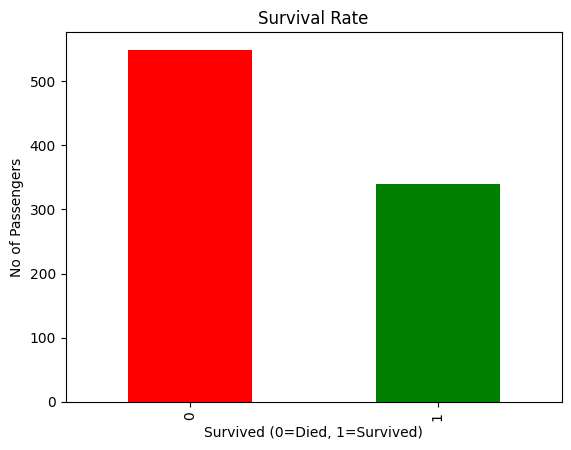

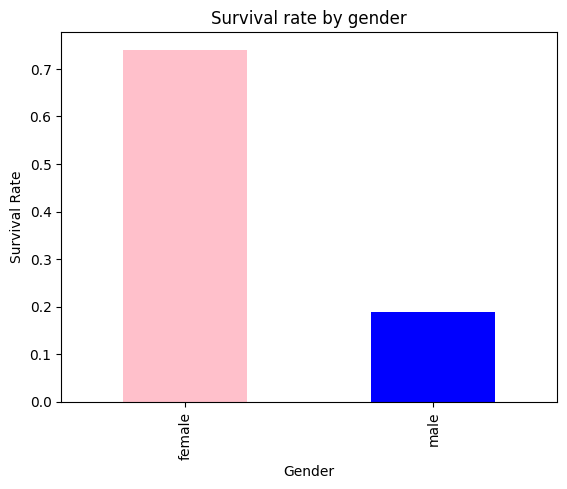

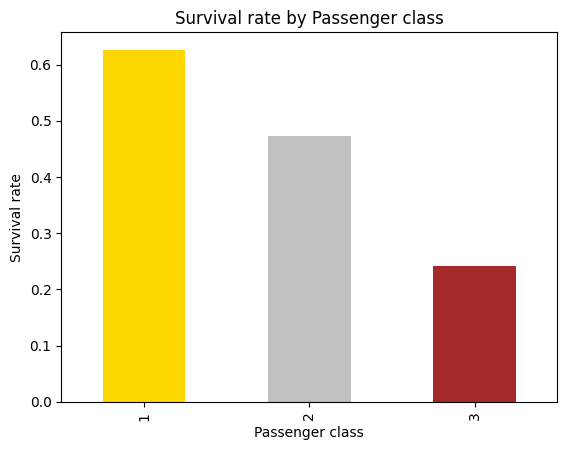

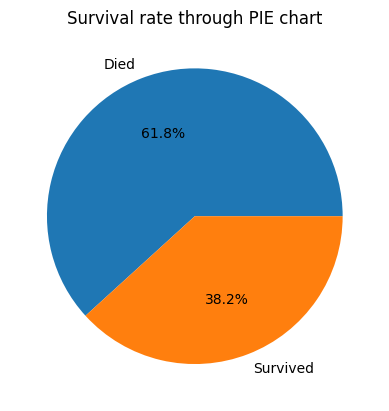

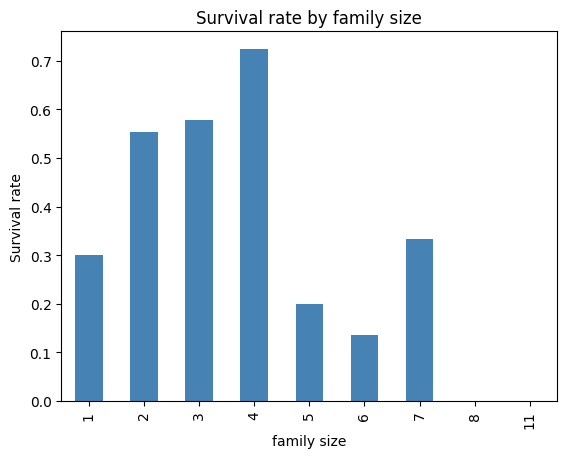

In [43]:
#Survival rate

df['Survived'].value_counts(). plot(kind='bar', color=['red','green'])
plt.title('Survival Rate')
plt.xlabel('Survived (0=Died, 1=Survived)')
plt.ylabel('No of Passengers')
plt.show()


#Survival rate by gender

df.groupby('Sex')['Survived'].mean(). plot(kind='bar', color=['pink', 'blue'])
plt.title('Survival rate by gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.show()


#Survival rate by passenger class

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color=['gold', 'silver', 'brown'])
plt.title('Survival rate by Passenger class')
plt.xlabel('Passenger class')
plt.ylabel('Survival rate')
plt.show()


#Pie chart

df['Survived'].value_counts(). plot(kind='pie',labels=['Died', 'Survived'], color=['red', 'green'] ,  autopct='%1.1f%%')
plt.title('Survival rate through PIE chart')
plt.ylabel('')
plt.show()


#Family size vs survival

df.groupby('FamilySize')['Survived'].mean().plot(kind='bar', color=['steelblue'])
plt.title('Survival rate by family size')
plt.xlabel('family size')
plt.ylabel('Survival rate')
pl

Conclusion
* Finding 1... the overall survival rate was 32.25, which means majority of the people were died on the scene
* Finding 2... Females were prioritized and almost 74% of females were rescued, but only 18% of males were survived
* Finding 3... The survival rate was also affected by the passenger class the first class passengers were rescued first and the rate of survival was almost 74%, this means majority of the first class people survived as compared to the other classes
* Finding 4... The age of passengers also affected the overall survival rate as the childeren survived the most after that the adults were at the highest rate of survival
* Finding 5... Family size hugely affected the survival rate as single people on board were not really able to survive, only some of them survived because no one was there for them to take care off, secondly the couples or people with tota 3 or 4 family members survived the most as it was easy for them to take care of eachother lastly people with big family sizes were not able for survive because it was very difficult to take care of every family member